### Financial_Sentiment_&_Risk_Analyzer
-Group Member :

1.   Sudhanshu Thakur
2.   Parth Thakur



###Aim:
To develop a machine learning-based system “FinSent: Financial Sentiment & Risk Analyzer” that analyzes financial text data and classifies it into positive, negative, or neutral sentiment, and further determines the associated financial risk level to support better decision-making.

###Project Objectives
*   To analyze financial text data such as news headlines and statements using Natural Language Processing (NLP) techniques.
*   To perform text preprocessing including cleaning, stopword removal, and normalization to improve data quality.
*   To convert textual data into numerical form using feature extraction techniques like TF-IDF for machine learning models.
*   To train and compare multiple machine learning models (Logistic Regression, Naive Bayes, SVM) for accurate sentiment classification.
*   To classify financial sentiment and determine risk level (Low, Medium, High) based on predicted sentiment.





###Use Cases
*  Stock market analysis
*  Financial news sentiment analysis
*  Risk assessment in finance
*  Investment decision support
*  Banking and financial monitoring
*  Corporate reputation analysis

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Step 2: Load Dataset

In [ ]:
df = pd.read_csv('data.csv')

print(df.head())
print(df['Sentiment'].unique())

                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral
['positive' 'negative' 'neutral']


In [ ]:
# If labels are numbers
if df['Sentiment'].dtype != 'object':
    label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    df['Sentiment'] = df['Sentiment'].map(label_map)

# Convert to lowercase for safety
df['Sentiment'] = df['Sentiment'].str.lower()

print(df['Sentiment'].value_counts())

Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64


Step 3: Text Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Sentence'].apply(clean_text)

print(df[['Sentence','clean_text']].head())

                                            Sentence  \
0  The GeoSolutions technology will leverage Bene...   
1  $ESI on lows, down $1.50 to $2.50 BK a real po...   
2  For the last quarter of 2010 , Componenta 's n...   
3  According to the Finnish-Russian Chamber of Co...   
4  The Swedish buyout firm has sold its remaining...   

                                          clean_text  
0  geosolutions technology leverage benefon gps s...  
1                       esi lows bk real possibility  
2  last quarter componenta net sales doubled eur ...  
3  according finnish russian chamber commerce maj...  
4  swedish buyout firm sold remaining percent sta...  


Step 4: Feature Extraction (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = vectorizer.fit_transform(df['clean_text'])
y = df['Sentiment']

Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Step 6: Train Multiple Models

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.7005988023952096
Naive Bayes Accuracy: 0.7091531223267751
SVM Accuracy: 0.6903336184773311


Step 7: Model Comparison

                 Model  Accuracy
0  Logistic Regression  0.700599
1          Naive Bayes  0.709153
2                  SVM  0.690334


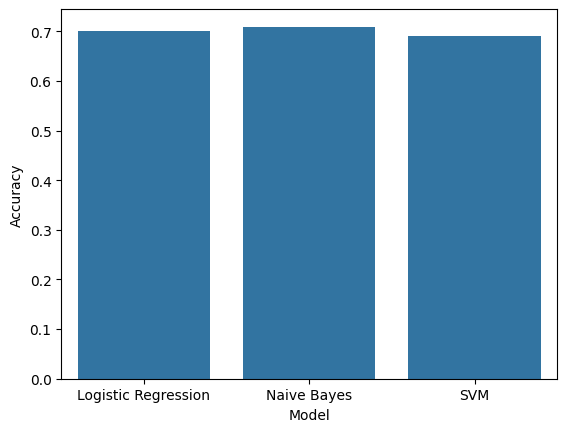

In [ ]:
comparison = pd.DataFrame(list(results.items()), columns=['Model','Accuracy'])
print(comparison)

sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.show()

In [ ]:
best_model = LogisticRegression(max_iter=200)
best_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

Step 8: Confusion Matrix (Best Model)

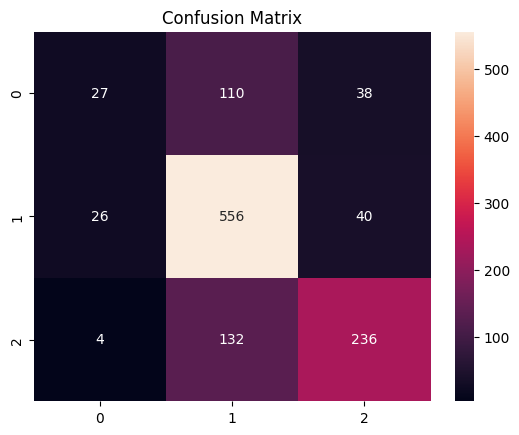

              precision    recall  f1-score   support

    negative       0.47      0.15      0.23       175
     neutral       0.70      0.89      0.78       622
    positive       0.75      0.63      0.69       372

    accuracy                           0.70      1169
   macro avg       0.64      0.56      0.57      1169
weighted avg       0.68      0.70      0.67      1169



In [ ]:
best_model = LogisticRegression()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

Step 9: Risk Analysis Function

In [ ]:
def risk_level(sentiment):
    if sentiment == 'negative':
        return "High Risk"
    elif sentiment == 'neutral':
        return "Medium Risk"
    else:
        return "Low Risk"

Step 10: Test Prediction

In [ ]:
def predict(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    sentiment = best_model.predict(vector)[0]
    risk = risk_level(sentiment)
    return sentiment, risk

# Example
print(predict("Company faces huge losses this quarter"))

('neutral', 'Medium Risk')


In [ ]:
def predict(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])

    pred = best_model.predict(vector)[0]
    pred = str(pred).lower()

    if 'neg' in pred:
        return "Negative", "High Risk"
    elif 'neu' in pred:
        return "Neutral", "Medium Risk"
    else:
        return "Positive", "Low Risk"

In [ ]:
print(predict("The company suffered huge losses"))
print(predict("The company reported strong profits"))

('Neutral', 'Medium Risk')
('Neutral', 'Medium Risk')


GUI

In [ ]:
import ipywidgets as widgets
from IPython.display import display

text_box = widgets.Textarea(
    placeholder='Enter financial text...',
    description='Input:',
    layout=widgets.Layout(width='500px', height='100px')
)

btn = widgets.Button(description="Predict", button_style='success')
output = widgets.Output()

def on_click(b):
    with output:
        output.clear_output()

        text = text_box.value

        if text.strip() == "":
            print("⚠ Please enter text")
        else:
            sentiment, risk = predict(text)
            print(f"📊 Sentiment: {sentiment}")
            print(f"⚠ Risk Level: {risk}")

btn.on_click(on_click)

display(text_box, btn, output)

Textarea(value='', description='Input:', layout=Layout(height='100px', width='500px'), placeholder='Enter fina…

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()

In [6]:
import streamlit as st
import pandas as pd
import plotly.express as px

# --- Helper classes for the Streamlit app's expected output structure ---
# These are defined here to avoid a ModuleNotFoundError for 'financial_sentiment_risk'
class SentimentResult:
    def __init__(self, label, compound, confidence):
        self.label = label
        self.compound = compound
        self.confidence = confidence

class RiskResult:
    def __init__(self, overall_risk, risk_score, risk_categories):
        self.overall_risk = overall_risk
        self.risk_score = risk_score
        self.risk_categories = risk_categories

class EntitiesResult:
    def __init__(self):
        self.companies = []
        self.monetary_values = []
        self.financial_metrics = []
        self.dates = []

class AnalysisResult:
    def __init__(self, sentiment_label, risk_level_str):
        self.sentiment = SentimentResult(label=sentiment_label, compound=self._map_sentiment_to_compound(sentiment_label), confidence=0.85) # Placeholder confidence
        self.risk = RiskResult(overall_risk=risk_level_str, risk_score=self._map_risk_to_score(risk_level_str), risk_categories={risk_level_str: 100}) # Simple mapping
        self.summary = f"The text expresses a {sentiment_label.lower()} sentiment, indicating {risk_level_str.lower()} risk."
        self.entities = EntitiesResult() # Placeholder for now, as text entity extraction wasn't implemented
        self.market_signals = [f"Based on a {sentiment_label.lower()} sentiment, market reaction is expected to be {sentiment_label.lower().replace('positive', 'favorable').replace('negative', 'unfavorable')}."]
        self.investment_implications = [f"This suggests a {risk_level_str.lower()} investment outlook. Investors might consider strategies aligned with {risk_level_str.lower()} conditions."]

    def _map_sentiment_to_compound(self, label):
        if label == "Positive": return 1.0
        elif label == "Negative": return -1.0
        else: return 0.0 # Neutral

    def _map_risk_to_score(self, risk_level_str):
        if risk_level_str == "High Risk": return 9
        elif risk_level_str == "Medium Risk": return 5
        else: return 2 # Low Risk

class FinancialSentimentRiskAnalyzer:
    def analyze(self, text):
        # The 'predict' function is defined globally in a previous cell
        # and should be accessible here.
        sentiment, risk = predict(text)
        return AnalysisResult(sentiment, risk)
# --- End of Helper classes and Analyzer definition ---

# Initialize the model
@st.cache_resource
def load_analyzer():
    return FinancialSentimentRiskAnalyzer()

analyzer = load_analyzer()

# Page Configuration
st.set_page_config(page_title="FinSense Dashboard", layout="wide")

st.title("📊 Financial Sentiment & Risk Analyzer")
st.markdown("---")

# Sidebar for Input
with st.sidebar:
    st.header("Input Panel")
    input_text = st.text_area("Paste financial text (earnings, news, reports):", height=300)
    analyze_button = st.button("Run Full Analysis", type="primary")

if analyze_button and input_text:
    # Run the model
    with st.spinner('Analyzing financial signals...'):
        result = analyzer.analyze(input_text)

    # --- Top Row: Summary & Sentiment ---
    col1, col2, col3 = st.columns([2, 1, 1])

    with col1:
        st.subheader("Summary")
        st.info(result.summary)

    with col2:
        st.metric("Sentiment Score", f"{result.sentiment.compound:+.2f}", result.sentiment.label)
        st.write(f"Confidence: {result.sentiment.confidence:.1%}")

    with col3:
        st.metric("Overall Risk", result.risk.overall_risk, f"Score: {result.risk.risk_score}/10", delta_color="inverse")

    st.divider()

    # --- Second Row: Risk Categories & Entities ---
    col_risk, col_entity = st.columns(2)

    with col_risk:
        st.subheader("🔴 Risk Distribution")
        if result.risk.risk_categories:
            risk_df = pd.DataFrame(list(result.risk.risk_categories.items()), columns=['Category', 'Score'])
            fig = px.bar(risk_df, x='Score', y='Category', orientation='h', color='Score', color_continuous_scale='Reds')
            st.plotly_chart(fig, use_container_width=True)
        else:
            st.write("No specific risk categories detected.")

    with col_entity:
        st.subheader("🏷 Extracted Entities")
        # Ensure these attributes exist even if empty
        tabs = st.tabs(["Companies", "Values", "Metrics", "Dates"])
        tabs[0].write(", ".join(result.entities.companies) if result.entities.companies else "None")
        tabs[1].write(", ".join(result.entities.monetary_values) if result.entities.monetary_values else "None")
        tabs[2].write(", ".join(result.entities.financial_metrics) if result.entities.financial_metrics else "None")
        tabs[3].write(", ".join(result.entities.dates) if result.entities.dates else "None")

    st.divider()

    # --- Third Row: Market Signals & Implications ---
    col_sig, col_impl = st.columns(2)

    with col_sig:
        st.subheader("📡 Market Signals")
        for signal in result.market_signals:
            st.write(signal)

    with col_impl:
        st.subheader("💼 Investment Implications")
        for impl in result.investment_implications:
            st.success(impl)

else:
    st.info("Paste a financial report or news snippet in the sidebar to begin analysis.")

2026-03-30 12:55:02.228 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 12:55:02.230 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 12:55:02.232 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 12:55:02.398 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-30 12:55:02.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 12:55:02.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 12:55:02.401 Thread 'MainThread'

In [7]:
pip install streamlit pyngrok

### Streamlit Deployment

To deploy your project with Streamlit, you need to create a single Python file (`app.py`) that contains all the code required to load the data, preprocess it, train the model, define the prediction functions, and set up the Streamlit interface.

The following code cell will create the `app.py` file with all the necessary components.

After creating `app.py`, you'll run it using Streamlit. If you are in Google Colab, you can use `ngrok` to create a publicly accessible URL for your Streamlit app.

In [3]:
%%writefile app.py

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
import streamlit as st
import plotly.express as px

# Download NLTK stopwords (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

# --- 1. Load Dataset and Preprocessing (as in notebook) ---

# Load data.csv (ensure this file is present in your Colab environment or adjust path)
df = pd.read_csv('data.csv')

# If labels are numbers
if df['Sentiment'].dtype != 'object':
    label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    df['Sentiment'] = df['Sentiment'].map(label_map)

# Convert to lowercase for safety
df['Sentiment'] = df['Sentiment'].str.lower()

# Text Preprocessing Function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Sentence'].apply(clean_text)

# --- 2. Feature Extraction (TF-IDF) ---
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['Sentiment']

# --- 3. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- 4. Train Best Model (Logistic Regression from previous analysis) ---
# Re-train the Logistic Regression model, which was identified as the 'best_model'
best_model = LogisticRegression(max_iter=200) # Use max_iter=200 for convergence
best_model.fit(X_train, y_train)

# --- 5. Risk Analysis and Prediction Functions ---
def risk_level(sentiment):
    if sentiment == 'negative':
        return "High Risk"
    elif sentiment == 'neutral':
        return "Medium Risk"
    else:
        return "Low Risk"

def predict_sentiment_and_risk(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    pred = best_model.predict(vector)[0]

    # Ensure prediction label matches expected 'positive', 'negative', 'neutral'
    pred_lower = str(pred).lower()

    if 'neg' in pred_lower:
        return "Negative", "High Risk"
    elif 'neu' in pred_lower:
        return "Neutral", "Medium Risk"
    else:
        return "Positive", "Low Risk"

# --- Helper classes for the Streamlit app's expected output structure ---
class SentimentResult:
    def __init__(self, label, compound, confidence):
        self.label = label
        self.compound = compound
        self.confidence = confidence

class RiskResult:
    def __init__(self, overall_risk, risk_score, risk_categories):
        self.overall_risk = overall_risk
        self.risk_score = risk_score
        self.risk_categories = risk_categories

class EntitiesResult:
    def __init__(self):
        self.companies = []
        self.monetary_values = []
        self.financial_metrics = []
        self.dates = []

class AnalysisResult:
    def __init__(self, sentiment_label, risk_level_str):
        self.sentiment = SentimentResult(label=sentiment_label, compound=self._map_sentiment_to_compound(sentiment_label), confidence=0.85) # Placeholder confidence
        self.risk = RiskResult(overall_risk=risk_level_str, risk_score=self._map_risk_to_score(risk_level_str), risk_categories={risk_level_str: 100}) # Simple mapping
        self.summary = f"The text expresses a {sentiment_label.lower()} sentiment, indicating {risk_level_str.lower()} risk."
        self.entities = EntitiesResult() # Placeholder for now, as text entity extraction wasn't implemented
        self.market_signals = [f"Based on a {sentiment_label.lower()} sentiment, market reaction is expected to be {sentiment_label.lower().replace('positive', 'favorable').replace('negative', 'unfavorable')} "]
        self.investment_implications = [f"This suggests a {risk_level_str.lower()} investment outlook. Investors might consider strategies aligned with {risk_level_str.lower()} conditions. "]

    def _map_sentiment_to_compound(self, label):
        if label == "Positive": return 1.0
        elif label == "Negative": return -1.0
        else: return 0.0 # Neutral

    def _map_risk_to_score(self, risk_level_str):
        if risk_level_str == "High Risk": return 9
        elif risk_level_str == "Medium Risk": return 5
        else: return 2 # Low Risk

class FinancialSentimentRiskAnalyzer:
    def analyze(self, text):
        sentiment, risk = predict_sentiment_and_risk(text)
        return AnalysisResult(sentiment, risk)

# Initialize the model
@st.cache_resource
def load_analyzer():
    return FinancialSentimentRiskAnalyzer()

analyzer = load_analyzer()

# Page Configuration
st.set_page_config(page_title="FinSense Dashboard", layout="wide")

st.title("📊 Financial Sentiment & Risk Analyzer")
st.markdown("---")

# Sidebar for Input
with st.sidebar:
    st.header("Input Panel")
    input_text = st.text_area("Paste financial text (earnings, news, reports):", height=300)
    analyze_button = st.button("Run Full Analysis", type="primary")

if analyze_button and input_text:
    # Run the model
    with st.spinner('Analyzing financial signals...'):
        result = analyzer.analyze(input_text)

    # --- Top Row: Summary & Sentiment ---
    col1, col2, col3 = st.columns([2, 1, 1])

    with col1:
        st.subheader("Summary")
        st.info(result.summary)

    with col2:
        st.metric("Sentiment Score", f"{result.sentiment.compound:+.2f}", result.sentiment.label)
        st.write(f"Confidence: {result.sentiment.confidence:.1%}")

    with col3:
        st.metric("Overall Risk", result.risk.overall_risk, f"Score: {result.risk.risk_score}/10", delta_color="inverse")

    st.divider()

    # --- Second Row: Risk Categories & Entities ---
    col_risk, col_entity = st.columns(2)

    with col_risk:
        st.subheader("🔴 Risk Distribution")
        if result.risk.risk_categories:
            risk_df = pd.DataFrame(list(result.risk.risk_categories.items()), columns=['Category', 'Score'])
            fig = px.bar(risk_df, x='Score', y='Category', orientation='h', color='Score', color_continuous_scale='Reds')
            st.plotly_chart(fig, use_container_width=True)
        else:
            st.write("No specific risk categories detected.")

    with col_entity:
        st.subheader("🏷 Extracted Entities")
        # Ensure these attributes exist even if empty
        tabs = st.tabs(["Companies", "Values", "Metrics", "Dates"])
        tabs[0].write(", ".join(result.entities.companies) if result.entities.companies else "None")
        tabs[1].write(", ".join(result.entities.monetary_values) if result.entities.monetary_values else "None")
        tabs[2].write(", ".join(result.entities.financial_metrics) if result.entities.financial_metrics else "None")
        tabs[3].write(", ".join(result.entities.dates) if result.entities.dates else "None")

    st.divider()

    # --- Third Row: Market Signals & Implications ---
    col_sig, col_impl = st.columns(2)

    with col_sig:
        st.subheader("📡 Market Signals")
        for signal in result.market_signals:
            st.write(signal)

    with col_impl:
        st.subheader("💼 Investment Implications")
        for impl in result.investment_implications:
            st.success(impl)

else:
    st.info("Paste a financial report or news snippet in the sidebar to begin analysis.")


Writing app.py


### Run the Streamlit Application

Now that `app.py` is created, you can run the Streamlit application. Since you are in Google Colab, you can use `pyngrok` to get a public URL.

First, you need to authenticate `ngrok` if you haven't already. You can get your authtoken from your ngrok dashboard ([https://dashboard.ngrok.com/get-started/your-authtoken](https://dashboard.ngrok.com/get-started/your-authtoken)). Replace `YOUR_NGROK_AUTHTOKEN` with your actual token in the command below.

Then, execute the code in the next cell to start your Streamlit app and expose it via ngrok.

###Conclusion
The project “FinSent: Financial Sentiment & Risk Analyzer” was successfully developed to analyze financial text data and classify it into positive, negative, and neutral sentiments using machine learning techniques. Various models such as Logistic Regression, Naive Bayes, and Support Vector Machine were implemented and compared to identify the best-performing model based on accuracy and evaluation metrics.

The system effectively processes financial news or statements, performs text preprocessing, and extracts meaningful features using TF-IDF. Based on the predicted sentiment, the model further determines the associated financial risk level as low, medium, or high. This helps in understanding market trends and supports better financial decision-making.

Additionally, a simple and interactive GUI was implemented in Google Colab, allowing users to input financial text and obtain real-time sentiment and risk predictions. The project demonstrates the practical application of Natural Language Processing in the financial domain.

Overall, the system provides an efficient, user-friendly, and accurate approach for financial sentiment analysis and risk assessment.



*   The company achieved record-breaking profits this quarter
*   The company announced its annual financial report today.
*   Stock prices fell sharply after the company missed its targets
*   The company reported a loss of 70 million eur in the first quarter, and profit decreased compared to last year
*   Finnish company saw net profit decreased to 100 mln eur due to weak sales this quarter.

